# Differential Usage Analysis with SplisosmFFT

This notebook demonstrates how to run differential usage analysis to find potential **RNA-binding protein (RBP)** regulators of genes with spatially variable isoform/peak/exon/junction usage.

1. **Spatial variability (SV) tests** — identify genes with spatially variable probe usage, and RBP genes with spatially variable expression.
3. **Differential usage (DU) test** — for SV-processed genes, test whether their probe usage co-varies with SV-RBP expression.
4. **Comparison** — compare the results of conditional and non-conditional differential usage tests, and between `SplisosmFFT` (rasterized) and `SplisosmNP` (vectorized).

Estimated runtime: ~10 min.

## Preliminary notes

While we use the [Visium HD FFPE mouse brain dataset](https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-mouse-brain-he-v4) (with probe quantification) for demonstration, the workflow is compatible with other types of large-scale spatial transcriptomics data and features, including:

- isoforms from long-read sequencing
- TREND peaks from 3' sequencing
- exons/junctions from in situ sequencing

Please check the [documentation](https://splisosm.readthedocs.io/en/latest/) and the [tutorial gallery](https://splisosm.readthedocs.io/en/latest/tutorials/gallery.html) for details on how to prepare your data, e.g., from Space Ranger outputs.

**Please be aware that differential association tests focus on variation within bins.** For example, this notebook analyzes whether the expression of an RBP in a bin is associated with the probe usage of a gene **in the same bin**, which is why we recommend running the analysis at 16um resolution or higher. It is **not for testing cross-bin associations**, e.g., whether the expression of an RBP in one subcellular bin is associated with the probe usage of a gene in neighboring subcellular compartments. There will be a separate tutorial for cross-bin association analysis in the future.

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import scipy.sparse as sp

import spatialdata as sd
from spatialdata import rasterize_bins
from spatialdata.models import TableModel
from anndata import AnnData

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.io import load_visiumhd_probe
from splisosm.utils import counts_to_ratios

/Users/jysumac/miniforge3/envs/splisosm_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)

## Configure paths and parameters

Here, we focus on a list of potential RNA processing regulators, which are RBP genes with either CLIP data from [POSTAR3](https://111.198.139.65/) or binding motifs from [CISBP-RNA](http://cisbp-rna.ccbr.utoronto.ca/). Feel free to modify the RBP gene list and create your own covariate table as needed.

In [3]:
# # RBP reference files
# rbp_motif_file = Path("path/to/cisbp-rna/mouse_pm/rbp_with_known_motif.txt")
# rbp_clip_file  = Path("path/to/POSTAR3/mouse.rbp_with_clip.txt")
# rbp_motif_genes = set(pd.read_csv(rbp_motif_file, header=None).iloc[:, 0].str.strip())
# rbp_clip_genes  = set(pd.read_csv(rbp_clip_file,  header=None).iloc[:, 0].str.strip())
# rbp_genes       = rbp_motif_genes | rbp_clip_genes
# print(f"CisBP-RNA (motif): {len(rbp_motif_genes)}  |  POSTAR3 (CLIP): {len(rbp_clip_genes)}")

rbp_genes = {
    'A1cf', 'Ago2', 'Ankhd1', 'Ankrd17', 'Apc', 'B020018G12Rik', 'Cbp', 'Celf',
    'Celf1', 'Celf2', 'Celf3', 'Celf4', 'Celf6', 'Cirbp', 'Cnot4', 'Cpeb2',
    'Cpeb3', 'Cpeb4', 'Cpsf6', 'Crebbp', 'Csda', 'Dazap1', 'ENSMUSG00000021927',
    'ENSMUSG00000049235', 'ENSMUSG00000056951', 'ENSMUSG00000089986',
    'ENSMUSG00000090049', 'Eif2s1', 'Eif4b', 'Elavl1', 'Elavl2', 'Elavl3',
    'Elavl4', 'Enox1', 'Enox2', 'Esrp1', 'Esrp2', 'Ezh2', 'Fam120a', 'Fmr1',
    'Fus', 'Fxr1', 'Fxr2', 'G3bp2', 'Gm10110', 'Gm12355', 'Gm5145', 'Gm7964',
    'Gm8991', 'Hnrnpa1', 'Hnrnpa2b1', 'Hnrnpa3', 'Hnrnpab', 'Hnrnpc', 'Hnrnpf',
    'Hnrnph1', 'Hnrnph2', 'Hnrnpk', 'Hnrnpl', 'Hnrnpr', 'Hnrpdl', 'Hnrpll',
    'Igf2bp1', 'Igf2bp2', 'Igf2bp3', 'Khdrbs1', 'Khdrbs2', 'Khdrbs3', 'Lin28a',
    'Lin28b', 'Matr3', 'Mbnl1', 'Mbnl2', 'Mbnl3', 'Mex3b', 'Mex3c', 'Mex3d',
    'Msi1', 'Msi2', 'Ncl', 'Nono', 'Nova1', 'Nova2', 'Pabpc1', 'Pabpc1l',
    'Pabpc2', 'Pabpc4', 'Pabpc5', 'Pabpc6', 'Pabpn1', 'Pcbp1', 'Pcbp2', 'Pcbp3',
    'Pcbp4', 'Pou5f1', 'Pprc1', 'Pspc1', 'Ptbp1', 'Ptbp2', 'Pum1', 'Pum2', 'Qk',
    'Raly', 'Ralyl', 'Rbfox1', 'Rbfox2', 'Rbfox3', 'Rbm10', 'Rbm24', 'Rbm28',
    'Rbm3', 'Rbm38', 'Rbm41', 'Rbm42', 'Rbm45', 'Rbm46', 'Rbm47', 'Rbm4b',
    'Rbm5', 'Rbm8a', 'Rbms1', 'Rbms2', 'Rbms3', 'Rbmx', 'Rbmxl2', 'Rbmxrt',
    'Rod1', 'Samd4', 'Samd4b', 'Sart3', 'Sf3b4', 'Sfpq', 'Snrnp70', 'Snrpa',
    'Snrpb2', 'Srrm4', 'Srsf1', 'Srsf10', 'Srsf12', 'Srsf2', 'Srsf3', 'Srsf4',
    'Srsf5', 'Srsf6', 'Srsf7', 'Srsf9', 'Syncrip', 'Taf15', 'Tardbp', 'Tia1',
    'Tial1', 'Ttp', 'Tut1', 'U2af2', 'Upf1', 'Ybx1', 'Ybx2', 'Ythdc1', 'Ythdc2',
    'Yy1', 'Zc3h10', 'Zcrb1', 'Zfp36', 'Zfp36l1', 'Zfp36l2', 'Zfp36l3'
}

print(f"Union: {len(rbp_genes)} RBP genes")

Union: 166 RBP genes


In [4]:
# Space Ranger outputs / cached SpatialData
visium_hd_outs = Path("/Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ffpe_mouse_cbs/")
sdata_zarr     = visium_hd_outs / "sdata_probe.filtered.zarr"

# Dataset / table identifiers — 16 µm throughout
dataset_id        = "Visium_HD_Mouse_Brain"
test_table        = "square_016um"
test_bins_element = f"{dataset_id}_square_016um"

# Probe annotation columns
group_iso_by           = "gene_ids"
candidate_gene_name_cols = ["gene_name", "gene_symbol", "gene_names"]

# Probe QC filters
min_counts  = 10
min_bin_pct = 0.01

## Load SpatialData

In [ ]:
%%time
# Load preprocessed SpatialData object with probe-level quantification
sdata = sd.read_zarr(sdata_zarr)

# Check the presence of the test table and the required columns
adata_probe = sdata.tables[test_table]
if group_iso_by not in adata_probe.var.columns:
    raise ValueError(f"{group_iso_by!r} not found in {test_table}.var")

gene_name_col = next(
    (c for c in candidate_gene_name_cols if c in adata_probe.var.columns), None
)
if gene_name_col is None:
    raise ValueError(f"None of {candidate_gene_name_cols} found in adata_probe.var")

print(f"table={test_table}  bins={test_bins_element}")
print(f"group_iso_by={group_iso_by!r}  gene_name_col={gene_name_col!r}")
print(f"Probes: {adata_probe.n_vars}   Spots: {adata_probe.n_obs}")

table=square_016um  bins=Visium_HD_Mouse_Brain_square_016um
group_iso_by='gene_ids'  gene_name_col='gene_name'
Probes: 55538   Spots: 98917
CPU times: user 12.6 s, sys: 4.04 s, total: 16.7 s
Wall time: 11.9 s


## Spatial variability tests

###  Find genes with spatially variable probe usage

We first test each multi-probe gene for spatially variable probe usage (within-gene ratios) using `SplisosmFFT` and `method="hsic-ir"`at 16 µm resolution.

In [6]:
%%time
model_sv = SplisosmFFT(neighbor_degree=1, rho=0.99)
model_sv.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key="array_col",
    row_key="array_row",
    layer="counts",
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
)
model_sv.test_spatial_variability(
    method="hsic-ir",
    ratio_transformation="none",
    n_jobs=-1,
    print_progress=True,
)

SV (hsic-ir): 100%|██████████| 6224/6224 [03:14<00:00, 31.92it/s]


CPU times: user 5min 19s, sys: 47.8 s, total: 6min 7s
Wall time: 3min 24s


In [7]:
# Define SV genes for DU targets based on FFT results (FDR < 0.01)
sv_res_fft = model_sv.get_formatted_test_results("sv").sort_values("pvalue_adj")
sv_probe_gene_list = sorted(set(sv_res_fft.loc[sv_res_fft["pvalue_adj"] < 0.01, "gene"].astype(str)))
print(f"SVP genes (FFT FDR<0.01): {len(sv_probe_gene_list)} / {len(sv_res_fft)} \n"
      f"Will use these {len(sv_probe_gene_list)} genes as downstream DU targets")

sv_res_fft.head(5)

SVP genes (FFT FDR<0.01): 192 / 6224 
Will use these 192 genes as downstream DU targets


,gene,statistic,pvalue,pvalue_adj
3964,Syt1,0.000003,0.000000e+00,0.000000e+00
3517,Map4,0.000005,0.000000e+00,0.000000e+00
1805,Gabbr1,0.000003,2.528068e-257,5.244899e-254
1463,Oxr1,0.000002,8.884746e-135,1.382467e-131
2276,Rabgap1l,0.000003,6.476995e-81,8.062563e-78


### Find RBP genes with spatially variable expression

We next test each RBP gene for spatially variable expression using `SplisosmFFT` and `method="hsic-gc"` at 16 µm resolution. Spatially variably expressed RBP genes will be used as covariates in the downstream conditional DU test.

First, build gene-level RBP table (sum probe counts to gene-level) and save to the same `SpatialData` object.

In [8]:
%%time
# Filter probes to RBP genes
probe_gene_arr = adata_probe.var[gene_name_col].values
present_rbp = sorted(g for g in rbp_genes if g in set(probe_gene_arr))
print(f"RBP genes in dataset: {len(present_rbp)} / {len(rbp_genes)}")

# Define probe → gene mapping for present RBP genes
rbp_probe_mask = adata_probe.var[gene_name_col].isin(present_rbp).values
probe_gene_sub = adata_probe.var.loc[rbp_probe_mask, gene_name_col].values
unique_rbp_genes = sorted(set(probe_gene_sub))
gene_to_idx = {g: i for i, g in enumerate(unique_rbp_genes)}
probe_to_gene = np.array([gene_to_idx[g] for g in probe_gene_sub])

n_rbp_probe = int(rbp_probe_mask.sum())
agg_mat = sp.csr_matrix(
    (np.ones(n_rbp_probe), (probe_to_gene, np.arange(n_rbp_probe))),
    shape=(len(unique_rbp_genes), n_rbp_probe),
)

# Sum probe counts → gene counts: (n_spots, n_rbp)
X_rbp_probes = adata_probe.layers["counts"].tocsr()[:, rbp_probe_mask]
X_rbp_genes = (X_rbp_probes @ agg_mat.T).tocsc()   # csc for rasterize_bins

# Build obs (copy spatial metadata from probe table)
var_df_rbp = pd.DataFrame({
    "gene_name": unique_rbp_genes,
    "gene_ids": unique_rbp_genes,  # dummy gene_ids
}, index=unique_rbp_genes)

adata_rbp = AnnData(
    X=X_rbp_genes,
    obs=adata_probe.obs.copy(),
    var=var_df_rbp,
    # copy over spatialdata_attrs for parsing region/instance keys
    uns=adata_probe.uns.copy(),
    obsm=adata_probe.obsm.copy(),
)
adata_rbp.layers["counts"] = X_rbp_genes
print(f"RBP gene table: {adata_rbp.n_obs} spots × {adata_rbp.n_vars} genes")

RBP genes in dataset: 143 / 166
RBP gene table: 98917 spots × 143 genes
CPU times: user 323 ms, sys: 140 ms, total: 463 ms
Wall time: 507 ms


In [9]:
# Add gene-level RBP table to SpatialData
sdata["square_016um_rbp_genes"] = TableModel.parse(adata_rbp)
sdata

SpatialData object, with associated Zarr store: /Users/jysumac/Projects/SPLISOSM_paper/data/visiumhd_ffpe_mouse_cbs/sdata_probe.filtered.zarr
├── Images
│     ├── 'Visium_HD_Mouse_Brain_full_image': DataTree[cyx] (3, 23947, 18872), (3, 11973, 9436), (3, 5986, 4718), (3, 2993, 2359), (3, 1496, 1179)
│     ├── 'Visium_HD_Mouse_Brain_hires_image': DataArray[cyx] (3, 6000, 4729)
│     ├── 'Visium_HD_Mouse_Brain_lowres_image': DataArray[cyx] (3, 600, 473)
│     └── 'rasterized_square_016um_counts': DataArray[cyx] (55538, 396, 314)
├── Shapes
│     ├── 'Visium_HD_Mouse_Brain_cell_segmentations': GeoDataFrame shape: (40222, 2) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_002um': GeoDataFrame shape: (6296688, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_008um': GeoDataFrame shape: (393543, 1) (2D shapes)
│     └── 'Visium_HD_Mouse_Brain_square_016um': GeoDataFrame shape: (98917, 1) (2D shapes)
└── Tables
      ├── 'cell_segmentations': AnnData (40222, 55538)
      ├── 'square_

Next, we run the SVE test (`method="hsic-gc"`) for RBP gene expression. Here,
`filter_single_iso_genes=False` keeps genes with only one feature, which is the case for all RBP genes since we have aggregated probe counts to the total count.

In [10]:
%%time
rbp_sv = SplisosmFFT()
rbp_sv.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name="square_016um_rbp_genes",
    col_key="array_col",
    row_key="array_row",
    layer="counts",
    group_iso_by=gene_name_col,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=False,  # every gene has exactly one entry (no probe-level info)
)
rbp_sv.test_spatial_variability(
    method="hsic-gc",
    print_progress=True,
)

SV (hsic-gc): 100%|██████████| 125/125 [00:00<00:00, 234.51it/s]


CPU times: user 1.46 s, sys: 288 ms, total: 1.75 s
Wall time: 719 ms


In [11]:
%%time
sv_res_rbp = rbp_sv.get_formatted_test_results("sv").sort_values("pvalue_adj")
sv_rbp_names = sv_res_rbp.loc[sv_res_rbp["pvalue_adj"] < 0.01, "gene"].astype(str).tolist()
print(f"Spatially variable RBP genes (FDR < 0.01): {len(sv_rbp_names)} / {len(sv_res_rbp)}")
sv_res_rbp.tail(5)

Spatially variable RBP genes (FDR < 0.01): 125 / 125
CPU times: user 669 μs, sys: 23 μs, total: 692 μs
Wall time: 684 μs


,gene,statistic,pvalue,pvalue_adj
120,Zc3h10,3.426719e-07,2.387772e-121,2.466707e-121
86,Rbms2,4.263304e-07,3.304639e-112,3.385901e-112
82,Rbm4b,2.577039e-07,1.471319e-108,1.495243e-108
79,Rbm41,2.310365e-07,1.099206e-82,1.108071e-82
24,Ezh2,2.376248e-07,2.735964e-48,2.735964e-48


## Differential probe usage vs RBP expression

In this section, we will test whether the usage of different probes for each spatially variably processed (SVP, FDR < 0.01) gene is associated with the expression of spatially variable RBP genes. A significant result may indicate the potential regulator of variable probe usage events. However, spatial autocorrelation is a major confounder that can lead to spurious associations. For example, RBP expression may correlate with some probe usage due to underlying hidden spatial structure such as cell-type distribution. To address this, we will compare two approaches:

- **Non-conditional test** (`method="hsic"`): tests raw probe ratios vs raw RBP expression through the multivariate correlation coefficient.
- **Conditional test** (`method="hsic-gp"`): tests usage association after removing confounding spatial structure using FFT-accelerated Gaussian process regression.

### Prepare filtered probe table (SVP genes only)

In [12]:
# Restrict probe table to SV-processed genes for the DU test
sv_probe_mask_var = adata_probe.var[gene_name_col].isin(sv_probe_gene_list)
adata_probe_svp = adata_probe[:, sv_probe_mask_var].copy()
print(f"Filtered probe table: {adata_probe_svp.n_obs} spots x {adata_probe_svp.n_vars} probes "
      f"({len(sv_probe_gene_list)} genes)")

sdata["square_016um_svp"] = TableModel.parse(adata_probe_svp)

Filtered probe table: 98917 spots x 649 probes (192 genes)


### Register the covariate table

To run the differential usage test, we pass a `(n_spots, n_covariates)` design matrix to `SplisosmFFT.setup_data()`. It can be one of the following:

1. An AnnData table of the SpatialData object (i.e., the `sdata.tables['square_016um_rbp_genes']` table we just registered). In this case, all features in table.var will be used as covariates.
2. List of column names in the AnnData table (e.g., `adata_probe_svp.obs.columns`). If categorical, the column will be one-hot encoded.
3. A user-provided DataFrame/array-like design matrix that shares the same spot index (e.g., `adata_probe_svp.obs_names`).

To register a custom covariate design matrix, make sure to:
1. Create an AnnData object with the covariate matrix as `.X` and spot IDs as `.obs_names`.
2. Add/copy necessary metadata such as `.uns['spatialdata_attrs']`, `.obs` and `.obsm` from the probe table to ensure the covariate table is properly aligned. 
3. Parse the AnnData object and link it to the SpatialData object. See [the spatialdata documentation](https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/tables.html#table-metadata-annotation-targets) for more details on how to create and register tables in the sdata object.

In [13]:
# Since all RBP genes are spatially variably expressed, the following will
# duplicate the RBP covariate matrix as a new table in the SpatialData
adata_rbp_cov = adata_rbp[:, sv_rbp_names].copy()
adata_rbp_cov.X = adata_rbp_cov.layers["counts"].tocsc()

# adata_rbp_cov.uns["spatialdata_attrs"] is already copied from adata_rbp, 
# so the following will work without additional metadata adjustments
sdata["square_016um_rbp_sve"] = TableModel.parse(adata_rbp_cov)

### Run conditional differential usage test

In [14]:
%%time
model_du_fft = SplisosmFFT(neighbor_degree=1, rho=0.99)
model_du_fft.setup_data(
    sdata=sdata,
    bins=test_bins_element, # the 16um bin for rasterization
    table_name="square_016um_svp", # probe counts from SVP genes
    design_mtx="square_016um_rbp_sve",    # gene counts from SVE RBPs
    col_key="array_col",
    row_key="array_row",
    layer="counts",
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
)
print(model_du_fft)

=== FFT SPLISOSM model for spatial isoform testings
- Number of genes: 192
- Number of observed spots: 98917
- Number of raster cells: 124344
- Number of covariates: 125
- Average number of isoforms per gene: 3.1041666666666665
=== Test results
- Spatial variability test: NA
- Differential usage test: NA
CPU times: user 157 ms, sys: 27 ms, total: 184 ms
Wall time: 189 ms


In [15]:
%%time
# conditional DU test
model_du_fft.test_differential_usage(
    method='hsic-gp',
    residualize="cov_only",
    n_jobs=-1,
    print_progress=True,
)
du_fft = model_du_fft.get_formatted_test_results("du").sort_values("pvalue_adj")
n_sig_fft = int((du_fft["pvalue_adj"] < 0.01).sum())
print(f"Significant gene-RBP pairs (FDR < 0.01, multi-testing correction per RBP): {n_sig_fft} / {len(du_fft)}")
du_fft.head(10)

DU [hsic-gp] factor chunks: 100%|██████████| 2/2 [00:16<00:00,  8.00s/it]

Significant gene-RBP pairs (FDR < 0.01, multi-testing correction per RBP): 2146 / 24000
CPU times: user 17.9 s, sys: 3.13 s, total: 21 s
Wall time: 16.1 s


,gene,covariate,statistic,pvalue,pvalue_adj
18327,Tlk1,Celf2,0.000051,1.329160e-41,2.551986e-39
14015,Map4,Ptbp2,0.000061,1.416121e-34,2.718953e-32
18299,Tlk1,Snrnp70,0.000038,2.361746e-31,4.534552e-29
18317,Tlk1,Dazap1,0.000035,3.226290e-29,6.194477e-27
14011,Map4,Ralyl,0.000050,1.717097e-28,3.296827e-26
14009,Map4,Rbfox2,0.000049,6.617653e-28,1.270589e-25
14064,Map4,Elavl2,0.000048,2.711018e-27,5.205155e-25
18260,Tlk1,Rbfox1,0.000033,4.701848e-27,9.027549e-25
18294,Tlk1,Srsf3,0.000032,9.226192e-27,1.771429e-24
14062,Map4,Elavl4,0.000047,1.866261e-26,3.583221e-24


### Visualize top RBP-gene pairs

In [16]:
def ensure_rasterized(sdata, bin_table: str, bin_element: str, layer: str = "counts"):
    raster_key = f"rasterized_{bin_table}_{layer}"
    if raster_key in sdata.images:
        return raster_key

    adata = sdata.tables[bin_table]
    adata.X = adata.layers[layer]
    if hasattr(adata.X, "tocsc") and getattr(adata.X, "format", None) != "csc":
        adata.X = adata.X.tocsc()

    sdata[raster_key] = rasterize_bins(
        sdata,
        bins=bin_element,
        table_name=bin_table,
        col_key="array_col",
        row_key="array_row",
    )
    return raster_key

First take a look at the spatial expression of the top RBP-gene pair (Celf2-Tlk1) to see if their spatial patterns are visually correlated.

In [17]:
def plot_rbp_svp_pair(
    sdata,
    bin_element: str,
    rbp_table: str,
    rbp_gene: str,
    svp_table: str,
    svp_gene: str,
    svp_gene_col: str = "gene_ids",
    max_probes: int = 4,
): 
    """Plot RBP spatial expression alongside SVP gene probe count maps in one row.""" 
    # ── load RBP expression raster ────────────────────────────────────────── 
    rbp_raster_key = ensure_rasterized(sdata, rbp_table, bin_element)
    rbp_cube = np.asarray(
        sdata[rbp_raster_key].sel(c=[rbp_gene]).values[0], dtype=float
    ) # (ny, nx)
    
    # ── load SVP probe count raster ─────────────────────────────────────────
    adata_svp = sdata.tables[svp_table]
    probe_var = adata_svp.var.copy()
    probe_names = probe_var.index[
        probe_var[svp_gene_col].astype(str) == str(svp_gene)
    ].tolist()
    probe_names = [p for p in probe_names if p in adata_svp.var_names][:max_probes]
    
    if not probe_names: 
        raise ValueError(f"No probes found for '{svp_gene}' in column '{svp_gene_col}'")
        
    svp_raster_key = ensure_rasterized(sdata, svp_table, bin_element)
    probe_cube = np.moveaxis(
        np.asarray(sdata[svp_raster_key].sel(c=probe_names).values, dtype=float), 0, -1
    ) # (ny, nx, n_probes)
    
    n_probes = probe_cube.shape[-1]
    n_cols = 1 + n_probes
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.2), squeeze=False) 
    
    # Panel 0: RBP expression 
    rbp_map = np.log1p(rbp_cube)
    im0 = axes[0, 0].imshow(rbp_map, cmap="Blues")
    axes[0, 0].set_title(f"RBP: {rbp_gene}\n(log1p counts)", fontsize=10)
    axes[0, 0].axis("off")
    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)
    
    # Panels 1…n_probes: SVP probe counts
    for i, probe in enumerate(probe_names): 
        c = probe_cube[:, :, i]
        c_map = np.log1p(c) 
        im = axes[0, i + 1].imshow(c_map, cmap="Purples") 
        axes[0, i + 1].set_title(f"{probe}\n(log1p counts)", fontsize=10) 
        axes[0, i + 1].axis("off") 
        fig.colorbar(im, ax=axes[0, i + 1], fraction=0.046, pad=0.04) 
        
    fig.suptitle(f"RBP gene (blue): {rbp_gene} === SVP gene (purple): {svp_gene}", fontsize=14, y=1.01) 
    fig.tight_layout() 
    plt.show()

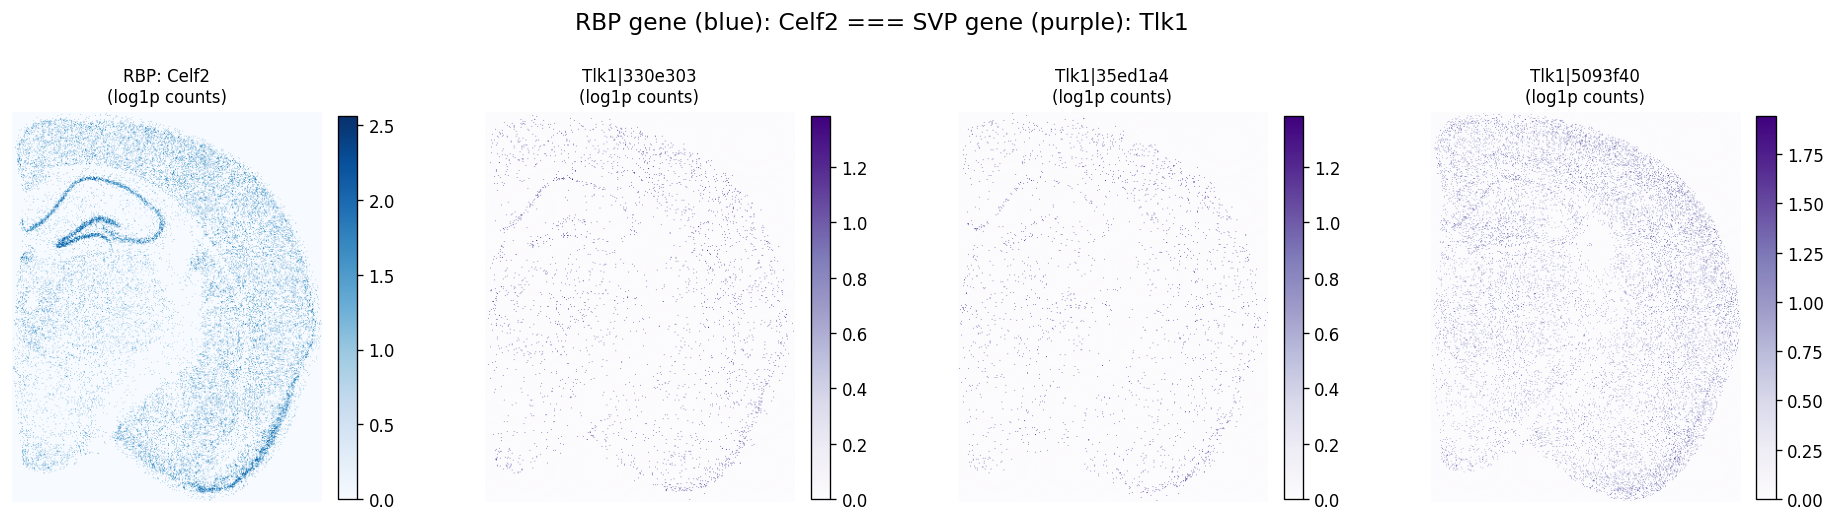

In [18]:
plot_rbp_svp_pair(
    sdata=sdata,
    bin_element=test_bins_element,
    rbp_table='square_016um_rbp_sve',
    rbp_gene='Celf2',
    svp_table='square_016um_svp',
    svp_gene='Tlk1',
    svp_gene_col=gene_name_col,
    max_probes=4,
)

We can also plot probe usage ratios as a function of RBP expression. Since the raw 16um-bin data is very sparse and the counts and ratios are almost binary, we will aggregate adjacent bins into meta bins (`meta_bin_size=4` gives 4*16 = 64um-by-64um meta bins) to get more robust estimates of probe usage ratios and RBP expression.

In [19]:
def plot_rbp_vs_probe_scatter(
    sdata,
    bin_element: str,
    rbp_table: str,
    rbp_gene: str,
    svp_table: str,
    svp_gene: str,
    svp_gene_col: str = "gene_ids",
    max_probes: int = 4,
    meta_bin_size: int = 4,
): 
    """Scatter plot: RBP expression (x) vs per-probe usage ratio (y) using meta bins.""" 
    import torch as _torch 
    import numpy as np
    from scipy.stats import spearmanr
    import matplotlib.pyplot as plt
    
    # ── load RBP expression ──────────────────────────────────────────────────
    rbp_raster_key = ensure_rasterized(sdata, rbp_table, bin_element) 
    rbp_cube = np.asarray(
        sdata[rbp_raster_key].sel(c=[rbp_gene]).values[0], 
        dtype=float
    ) # (ny, nx) 
    
    # ── load SVP probe data ────────────────────────────────────────────────── 
    adata_svp = sdata.tables[svp_table] 
    probe_var = adata_svp.var.copy() 
    probe_names = probe_var.index[
        probe_var[svp_gene_col].astype(str) == str(svp_gene)
    ].tolist() 
    probe_names = [p for p in probe_names if p in adata_svp.var_names][:max_probes] 
    
    if not probe_names: 
        raise ValueError(f"No probes found for '{svp_gene}'") 
        
    svp_raster_key = ensure_rasterized(sdata, svp_table, bin_element) 
    probe_cube = np.moveaxis(
        np.asarray(sdata[svp_raster_key].sel(c=probe_names).values, dtype=float), 
        0, -1
    ) # (ny, nx, n_probes) 
    
    # ── Aggregate into meta bins ─────────────────────────────────────────────
    ny, nx = rbp_cube.shape
    k = meta_bin_size
    
    if k > 1:
        # Trim dimensions to be exactly divisible by meta_bin_size
        ny_trim = (ny // k) * k
        nx_trim = (nx // k) * k
        
        # Aggregate RBP counts
        rbp_trimmed = rbp_cube[:ny_trim, :nx_trim]
        rbp_agg = rbp_trimmed.reshape(ny_trim // k, k, nx_trim // k, k).sum(axis=(1, 3))
        rbp_flat = rbp_agg.ravel()
        
        # Aggregate SVP probe counts
        probe_trimmed = probe_cube[:ny_trim, :nx_trim, :]
        n_probes = probe_trimmed.shape[-1]
        probe_agg = probe_trimmed.reshape(ny_trim // k, k, nx_trim // k, k, n_probes).sum(axis=(1, 3))
        probe_flat = probe_agg.reshape(-1, n_probes)
    else:
        rbp_flat = rbp_cube.ravel()
        probe_flat = probe_cube.reshape(-1, probe_cube.shape[-1])
    
    # Compute within-gene usage ratios across all probes of this gene (on meta bins)
    all_count_flat = probe_flat # (n_meta_grid, n_probes) 
    ratios_flat = counts_to_ratios(
        _torch.from_numpy(all_count_flat.astype(np.float32)), 
        transformation="none", 
        nan_filling="none",
    ).numpy() # (n_meta_grid, n_probes) 
    
    n_probes = len(probe_names) 
    fig, axes = plt.subplots(1, n_probes, figsize=(4 * n_probes, 4), squeeze=False) 
    
    for i, probe in enumerate(probe_names): 
        ratio_k = ratios_flat[:, i] # usage ratio for this probe 
        count_k = probe_flat[:, i] # raw count 
        
        # keep meta bins where RBP is expressed AND probe is detected 
        valid = (
            np.isfinite(rbp_flat) & 
            np.isfinite(ratio_k) & 
            (rbp_flat > 0) & 
            (count_k > 0)
        ) 
        
        x_v = np.log1p(rbp_flat[valid]) 
        y_v = ratio_k[valid] 
        
        rho, pval = spearmanr(x_v, y_v) if valid.sum() > 10 else (np.nan, np.nan) 
        rho_str = f"{rho:.2f}" if np.isfinite(rho) else "NA" 
        p_str = f"{pval:.2e}" if np.isfinite(pval) else "NA" 
        
        ax = axes[0, i] 
        ax.scatter(x_v, y_v, s=5, alpha=0.4, rasterized=True, color="steelblue") 
        
        # regression line 
        if valid.sum() > 10: 
            m, b = np.polyfit(x_v, y_v, 1) 
            x_line = np.linspace(x_v.min(), x_v.max(), 100) 
            ax.plot(x_line, m * x_line + b, "r-", linewidth=1.5, alpha=0.7) 
            
        ax.set_xlabel(f"{rbp_gene} (log1p counts)", fontsize=10) 
        ax.set_ylabel("Probe usage ratio", fontsize=9) 
        ax.set_title(f"{probe}\nSpearman ρ={rho_str} pval={p_str}", fontsize=10) 
        
    fig.suptitle(f"RBP gene: {rbp_gene} === SVP gene: {svp_gene} === Meta-bin size: {k}*16 x {k}*16 um", fontsize=14, y=1.02) 
    fig.tight_layout() 
    plt.show()

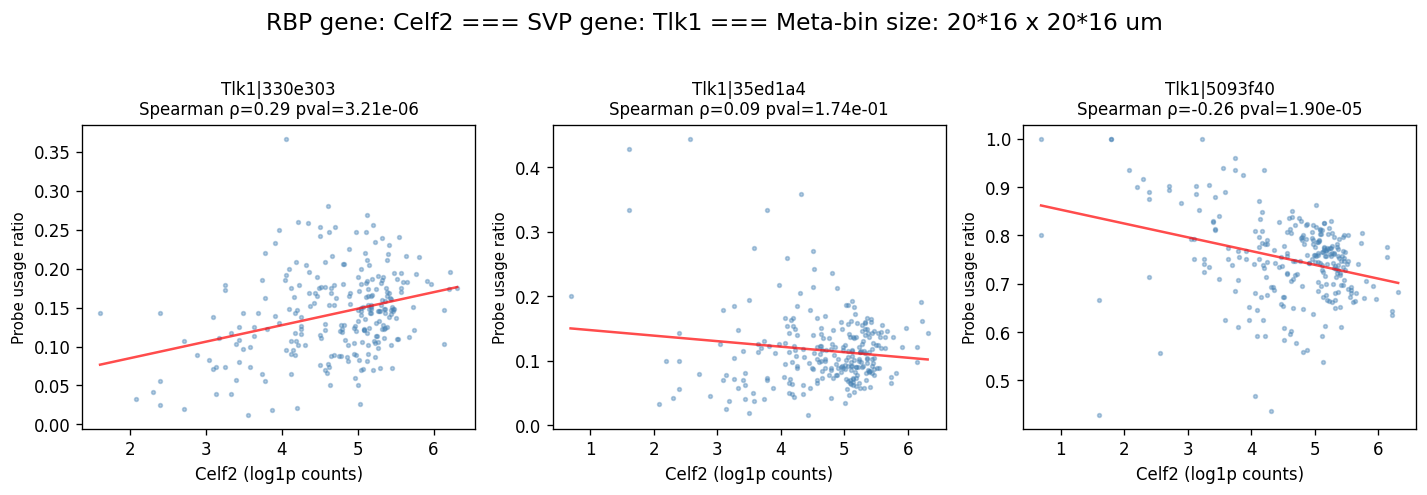

In [20]:
plot_rbp_vs_probe_scatter(
    sdata=sdata,
    bin_element=test_bins_element,
    rbp_table='square_016um_rbp_sve',
    rbp_gene='Celf2',
    svp_table='square_016um_svp',
    svp_gene='Tlk1',
    svp_gene_col=gene_name_col,
    max_probes=4,
    meta_bin_size=20,
)

## Advanced analyses

### Effect of spatial conditioning and residualization strategy

The default differential usage test checks the association between probe usage and RBP expression after removing spatial effects. To see how spatial conditioning affects the results, we can compare the results of the conditional test (`method="hsic-gp"`) with a non-conditional test (`method="hsic"`).

#### (a) Unconditional HSIC (multivariate correlation)

In [21]:
%%time
# unconditional DU test
model_du_fft.test_differential_usage(
    method='hsic',
    n_jobs=-1,
    print_progress=True,
)
du_fft_hsic = model_du_fft.get_formatted_test_results("du")
du_fft_hsic = du_fft_hsic.rename(columns={
    "pvalue": "pvalue_fft_hsic",
    "statistic": "stat_fft_hsic"
})
print(f"Significant DU pairs (p<0.01, hsic): {(du_fft_hsic['pvalue_fft_hsic'] < 0.01).sum()} / {len(du_fft_hsic)}")

DU [hsic] factor chunks: 100%|██████████| 2/2 [00:13<00:00,  6.70s/it]

Significant DU pairs (p<0.01, hsic): 5236 / 24000
CPU times: user 15.3 s, sys: 4.64 s, total: 19.9 s
Wall time: 13.5 s


#### (b) Conditional HSIC-GP, residualize covariates only (default)

In [ ]:
%%time
# conditional DU test
model_du_fft.test_differential_usage(
    method='hsic-gp',
    residualize="cov_only",
    n_jobs=-1,
    print_progress=True,
)
du_fft_gp_cov = model_du_fft.get_formatted_test_results("du")
du_fft_gp_cov = du_fft_gp_cov.rename(columns={
    "pvalue": "pvalue_fft_gp_cov",
    "statistic": "stat_fft_gp_cov"
})
print("Significant DU pairs (p<0.01, hsic-gp, cov only): "
      f"{(du_fft_gp_cov['pvalue_fft_gp_cov'] < 0.01).sum()} / {len(du_fft_gp_cov)}")


DU [hsic-gp] factor chunks: 100%|██████████| 2/2 [00:17<00:00,  8.65s/it]

Significant DU pairs (p<0.01, hsic-gp, cov only): 4100 / 24000
CPU times: user 18.8 s, sys: 4.07 s, total: 22.9 s
Wall time: 17.4 s


#### (c) Conditional HSIC-GP, residualize both covariates and probe usage ratios

In [23]:
%%time
# conditional DU test
model_du_fft.test_differential_usage(
    method='hsic-gp',
    residualize="both", # the slowest
    n_jobs=-1,
    print_progress=True,
)
du_fft_gp_both = model_du_fft.get_formatted_test_results("du")
du_fft_gp_both = du_fft_gp_both.rename(columns={
    "pvalue": "pvalue_fft_gp_both",
    "statistic": "stat_fft_gp_both"
})
print("Significant DU pairs (p<0.01, hsic-gp, both): " 
      f"{(du_fft_gp_both['pvalue_fft_gp_both'] < 0.01).sum()} / {len(du_fft_gp_both)}")

DU [hsic-gp] factor chunks: 100%|██████████| 2/2 [00:31<00:00, 15.91s/it]

Significant DU pairs (p<0.01, hsic-gp, both): 3822 / 24000
CPU times: user 55.8 s, sys: 6.29 s, total: 1min 2s
Wall time: 31.9 s


#### (d) Compare conditional vs non-conditional test results

In [25]:
def _neg_log10(p, floor=1e-300):
    return -np.log10(np.clip(p, floor, 1.0))

merge_cols = ["gene", "covariate"]

fft_all = (
    du_fft_hsic[merge_cols + ["pvalue_fft_hsic"]]
    .merge(du_fft_gp_cov[merge_cols + ["pvalue_fft_gp_cov"]], on=merge_cols, how="inner")
    .merge(du_fft_gp_both[merge_cols + ["pvalue_fft_gp_both"]], on=merge_cols, how="inner")
)
print(f"FFT gene-RBP pairs (inner join): {len(fft_all)}")

# Spearman correlations between FFT methods
rho_h_gc, _  = spearmanr(fft_all["pvalue_fft_hsic"],    fft_all["pvalue_fft_gp_cov"])
rho_h_gb, _  = spearmanr(fft_all["pvalue_fft_hsic"],    fft_all["pvalue_fft_gp_both"])
rho_gc_gb, _ = spearmanr(fft_all["pvalue_fft_gp_cov"],  fft_all["pvalue_fft_gp_both"])
print(f"Spearman ρ(hsic, hsic-gp cov_only) = {rho_h_gc:.3f}")
print(f"Spearman ρ(hsic, hsic-gp both)     = {rho_h_gb:.3f}")
print(f"Spearman ρ(hsic-gp cov, hsic-gp both) = {rho_gc_gb:.3f}")


FFT gene-RBP pairs (inner join): 24000
Spearman ρ(hsic, hsic-gp cov_only) = 0.939
Spearman ρ(hsic, hsic-gp both)     = 0.891
Spearman ρ(hsic-gp cov, hsic-gp both) = 0.986


As expected, spatial conditioning mostly calibrates the p-values and reduces the number of significant hits, but the overall gene×factor pair rankings are highly correlated (Spearman's rho = 0.89). Also, residualizing covariates only vs both covariates and probe usage ratios gives highly similar results (Spearman's rho = 0.99), suggesting that the default approach is effective and robust.

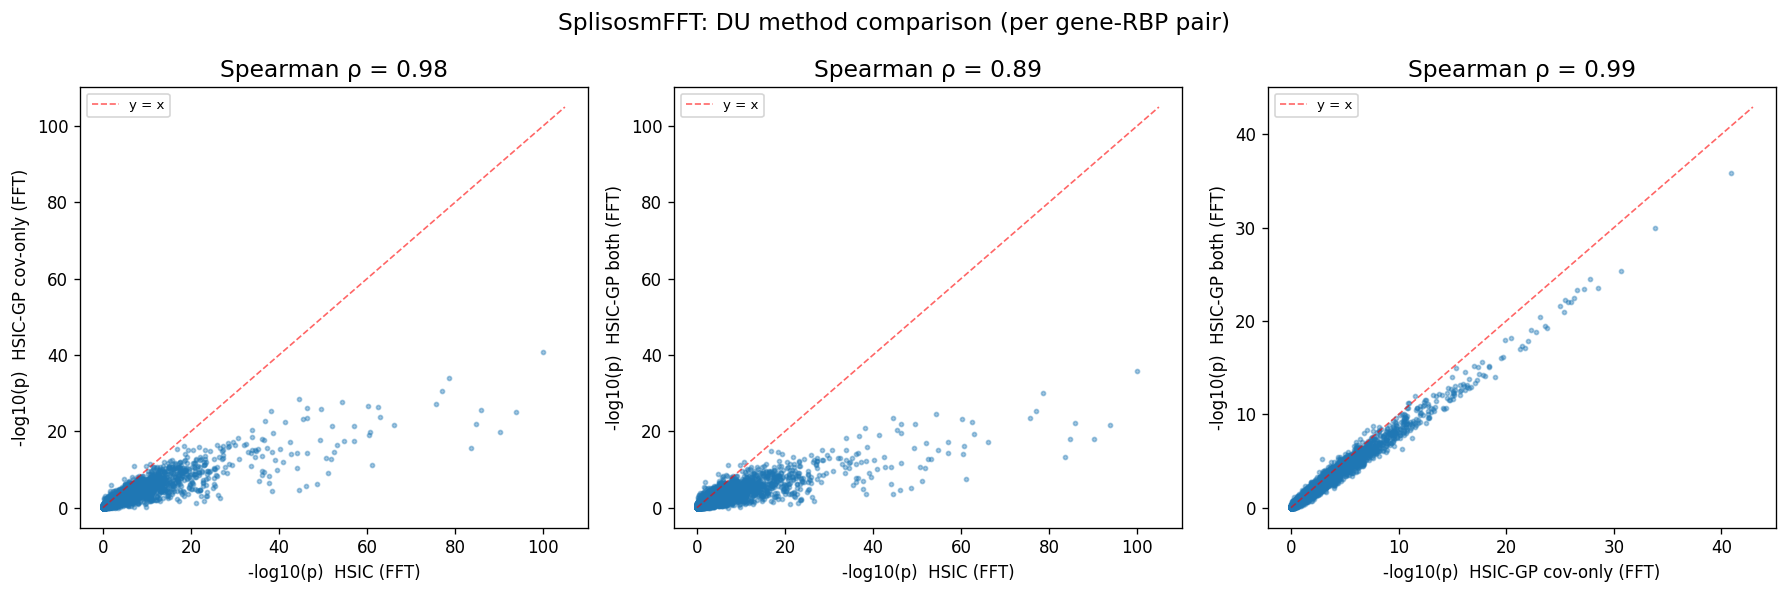

In [56]:
pairs_fft = [
    ("pvalue_fft_hsic",    "pvalue_fft_gp_cov",
     "HSIC (FFT)",          "HSIC-GP cov-only (FFT)",  rho_h_gc),
    ("pvalue_fft_hsic",    "pvalue_fft_gp_both",
     "HSIC (FFT)",          "HSIC-GP both (FFT)",       rho_h_gb),
    ("pvalue_fft_gp_cov",  "pvalue_fft_gp_both",
     "HSIC-GP cov-only (FFT)", "HSIC-GP both (FFT)",   rho_gc_gb),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (cx, cy, lx, ly, rho) in zip(axes, pairs_fft):
    x = _neg_log10(fft_all[cx].astype(float).values, floor=1e-100)
    y = _neg_log10(fft_all[cy].astype(float).values, floor=1e-100)
    ax.scatter(x, y, s=6, alpha=0.4, rasterized=True)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", linewidth=1, alpha=0.6, label="y = x")
    ax.set_xlabel(f"-log10(p)  {lx}", fontsize=10)
    ax.set_ylabel(f"-log10(p)  {ly}", fontsize=10)
    ax.set_title(f"Spearman ρ = {rho:.2f}", fontsize=14)
    ax.legend(fontsize=8)

fig.suptitle("SplisosmFFT: DU method comparison (per gene-RBP pair)", fontsize=14)
fig.tight_layout()
plt.show()

### Method comparison: `SplisosmFFT` vs `SplisosmNP`

Finally, let's check the agreement between the FFT-accelerated `SplisosmFFT` and the original vectorized `SplisosmNP` implementations of the conditional DU test.

In [29]:
%%time
model_du_np = SplisosmNP()
model_du_np.setup_data(
    adata=sdata.tables['square_016um_svp'],
    design_mtx=sdata.tables['square_016um_rbp_sve'].layers['counts'],
    covariate_names=sdata.tables['square_016um_rbp_sve'].var[gene_name_col].values,
    spatial_key="spatial",
    layer="counts",
    # kernel rank is not relevant for DU testing
    # but still affects setup_data runtime
    approx_rank=20,
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
)
print(model_du_np)

=== Non-parametric SPLISOSM model for spatial isoform testings
- Number of genes: 192
- Number of spots: 98917
- Number of covariates: 125
- Average number of isoforms per gene: 3.1041666666666665
=== Test results
- Spatial variability test: NA
- Differential usage test: NA
CPU times: user 46.4 s, sys: 3.15 s, total: 49.6 s
Wall time: 24.8 s


#### Run unconditional HSIC test with `SplisosmNP`

In [30]:
%%time
# Non-conditional: multivariate RV coefficient (no spatial residualization)
model_du_np.test_differential_usage(
    method="hsic", 
    print_progress=True
)
du_np_hsic = model_du_np.get_formatted_test_results("du")
du_np_hsic = du_np_hsic.rename(columns={
    "pvalue": "pvalue_np_hsic",
    "statistic": "stat_np_hsic"
})
print(f"Significant DU (p<0.01, hsic): {(du_np_hsic['pvalue_np_hsic'] < 0.01).sum()}")

100%|██████████| 192/192 [00:57<00:00,  3.35it/s]

Significant DU (p<0.01, hsic): 4042
CPU times: user 1min 17s, sys: 15.2 s, total: 1min 32s
Wall time: 57.4 s


#### Run conditional HSIC-GP test with `SplisosmNP`

By default, `SplisosmNP` calls Sklearn's `GaussianProcessRegressor` for spatial residualization. When the number of spots is large, full eigendecomposition becomes computationally infeasible. For illustration, we will pass `n_inducing=1000` to the kernel regression model, meaning that a random subset of 1000 bins is used for hyperparameter optimization. See `splisosm.kernel_gpr.FFTKernelGPR` for details.

In [40]:
%%time
from sklearn.exceptions import ConvergenceWarning
# Conditional: spatially residualize both probe usage and RBP expression
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning, message=".*is close to the specified.*")
    model_du_np.test_differential_usage(
        method="hsic-gp", 
        residualize="cov_only", 
        # inducing point approximation for faster GP fitting
        gpr_configs={"covariate": {"n_inducing": 1000}},
        print_progress=True
    )
du_np_gp_cov = model_du_np.get_formatted_test_results("du")
du_np_gp_cov = du_np_gp_cov.rename(columns={
    "pvalue": "pvalue_np_gp_cov",
    "statistic": "stat_np_gp_cov"
})
print(f"Significant DU (p<0.01, hsic-gp cov only): {(du_np_gp_cov['pvalue_np_gp_cov'] < 0.01).sum()}")

100%|██████████| 192/192 [00:53<00:00,  3.59it/s]

Significant DU (p<0.01, hsic-gp cov only): 3823
CPU times: user 3min 37s, sys: 1min 2s, total: 4min 39s
Wall time: 4min 1s


#### Compare conditional vs non-conditional test results, and `SplisosmFFT` vs `SplisosmNP`

In [42]:
def _neg_log10(p, floor=1e-300):
    return -np.log10(np.clip(p, floor, 1.0))

merge_cols = ["gene", "covariate"]

du_all = (
    du_fft_hsic[merge_cols + ["pvalue_fft_hsic"]]
    .merge(du_fft_gp_cov[merge_cols + ["pvalue_fft_gp_cov"]], on=merge_cols, how="inner")
    .merge(du_np_hsic[merge_cols + ["pvalue_np_hsic"]], on=merge_cols, how="inner")
    .merge(du_np_gp_cov[merge_cols + ["pvalue_np_gp_cov"]], on=merge_cols, how="inner")
)

# Spearman correlations between NP methods
rho_h_gc, _  = spearmanr(du_all["pvalue_np_hsic"],    du_all["pvalue_np_gp_cov"])
print(f"Spearman ρ(hsic, hsic-gp cov_only, SplisosmNP) = {rho_h_gc:.3f}")

# Spearman correlations between FFT and NP methods
rho_h, _  = spearmanr(du_all["pvalue_np_hsic"],    du_all["pvalue_fft_hsic"])
rho_gc, _ = spearmanr(du_all["pvalue_np_gp_cov"],  du_all["pvalue_fft_gp_cov"])
print(f"Spearman ρ(hsic, SplisosmNP vs SplisosmFFT) = {rho_h:.3f}")
print(f"Spearman ρ(hsic-gp cov_only, SplisosmNP vs SplisosmFFT) = {rho_gc:.3f}")


Spearman ρ(hsic, hsic-gp cov_only, SplisosmNP) = 0.979
Spearman ρ(hsic, SplisosmNP vs SplisosmFFT) = 1.000
Spearman ρ(hsic-gp cov_only, SplisosmNP vs SplisosmFFT) = 0.944


Due to rasterization (zero padding at unobserved bins), `SplisosmFFT`'s DU results will be slightly different from `SplisosmNP`'s, but the overall gene-factor pair rankings are still highly correlated (Spearman's rho = 0.88).

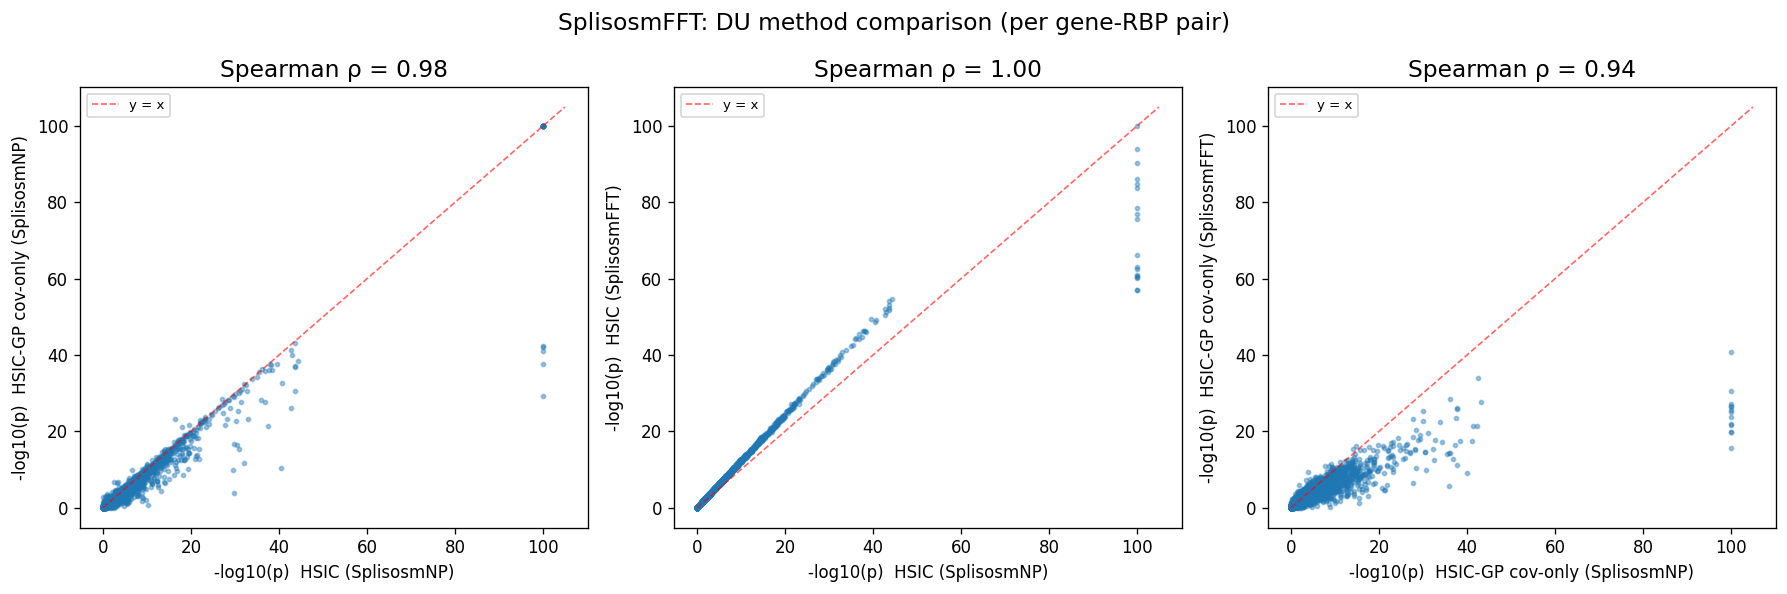

In [57]:
pairs_du = [
    ("pvalue_np_hsic",    "pvalue_np_gp_cov",
     "HSIC (SplisosmNP)", "HSIC-GP cov-only (SplisosmNP)",  rho_h_gc),
    ("pvalue_np_hsic",    "pvalue_fft_hsic",
     "HSIC (SplisosmNP)", "HSIC (SplisosmFFT)",  rho_h),
    ("pvalue_np_gp_cov",  "pvalue_fft_gp_cov",
     "HSIC-GP cov-only (SplisosmNP)", "HSIC-GP cov-only (SplisosmFFT)",   rho_gc),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (cx, cy, lx, ly, rho) in zip(axes, pairs_du):
    x = _neg_log10(du_all[cx].astype(float).values, floor=1e-100)
    y = _neg_log10(du_all[cy].astype(float).values, floor=1e-100)
    ax.scatter(x, y, s=6, alpha=0.4, rasterized=True)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", linewidth=1, alpha=0.6, label="y = x")
    ax.set_xlabel(f"-log10(p)  {lx}", fontsize=10)
    ax.set_ylabel(f"-log10(p)  {ly}", fontsize=10)
    ax.set_title(f"Spearman ρ = {rho:.2f}", fontsize=14)
    ax.legend(fontsize=8)

fig.suptitle("SplisosmFFT: DU method comparison (per gene-RBP pair)", fontsize=14)
fig.tight_layout()
plt.show()

## For reproducibility

In [35]:
import sys
from datetime import date
import splisosm

print("Last updated:", date.today())
print("Python:", sys.version.split()[0])
print("splisosm:", getattr(splisosm, "__version__", "unknown"))
print("spatialdata:", sd.__version__)

Last updated: 2026-03-26
Python: 3.12.12
splisosm: 1.0.4
spatialdata: 0.7.2
